<a href="https://colab.research.google.com/github/ved-aiml/Digit_classification_from_scratch/blob/main/mnist_neural_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.datasets import mnist
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()



In [2]:
X_train.shape

(60000, 28, 28)

In [3]:
X_train=X_train/255
X_test=X_test/255
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

y_train = ohe.fit_transform(y_train.reshape(-1, 1))
y_test = ohe.transform(y_test.reshape(-1, 1))

In [4]:
def initialise_parameters(list_num_nodes_in_each_layer):
    np.random.seed(3)
    l=len(list_num_nodes_in_each_layer)
    parameters={}
    for x in range(1,l):
        parameters['w'+str(x)] = np.random.randn(list_num_nodes_in_each_layer[x-1],list_num_nodes_in_each_layer[x]) * np.sqrt(2/list_num_nodes_in_each_layer[x-1])
        # parameters['w'+str(x)]=np.ones((list_num_nodes_in_each_layer[x-1],list_num_nodes_in_each_layer[x]))*0.01
        parameters['b'+str(x)]=np.zeros((list_num_nodes_in_each_layer[x],1))
    return parameters

In [5]:
# Flatten 28x28 images into 784 columns
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
print(type(X_train),X_train.shape,type(X_train_flat),X_train_flat.shape)

<class 'numpy.ndarray'> (60000, 28, 28) <class 'numpy.ndarray'> (60000, 784)


In [6]:
def output(prev_output,w,b):
    ans=np.dot(w.T,prev_output)+b
    return ans

In [7]:
def relu(z):
  return np.maximum(0, z)

In [8]:
def softmax(z):
    z = z - np.max(z, axis=0, keepdims=True)   # numerical stability
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)


In [9]:
def forward_prop(X, parameters):
    intermediates = {}
    o = X
    intermediates['o0'] = X
    L = len(parameters) // 2

    for l in range(1, L + 1):
        w = parameters['w' + str(l)]
        b = parameters['b' + str(l)]

        # Linear step
        z = output(o,w,b)
        intermediates['z' + str(l)] = z

        # Activation step
        if l == L:  #for output layer
            #print("z stats:", np.min(z), np.max(z))
            if(np.min(z)<-500):
              break
            o = softmax(z)
        else:        # hidden layers
            o = relu(z)
        intermediates['o' + str(l)] = o

    return o,intermediates

In [10]:
def cross_cat_entropy(y, y_hat):
    epsilon = 1e-12
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    m = y.shape[1]  # number of samples
    loss = - (1/m) * np.sum(y * np.log(y_hat))
    return loss

In [11]:
def cross_cat_entropy2(y, y_hat):
    eps = 1e-12
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.sum(y * np.log(y_hat))


In [12]:
def update_parameters(parameters, y, y_hat, intermediates, learning_rate):
    L = len(parameters) // 2

    grads = {}


     #output layer gradient
    dZ = y_hat - y
    o_prev = intermediates['o2']
    grads['dw' + str(L)] = np.dot(dZ, o_prev.T)
    grads['db' + str(L)] = dZ

    #update output layer parameters
    parameters['w' + str(L)] -= learning_rate * (grads['dw' + str(L)].T)
    parameters['b' + str(L)] -= learning_rate * grads['db' + str(L)]


    # Hidden layers (L-1 to 1)
    dZ_next = dZ
    for l in reversed(range(1, L)):
        z_current = intermediates['z' + str(l)]
        o_prev = intermediates['o' + str(l-1)]  # o0 = X

        # ReLU derivative
        dZ = np.dot(parameters['w' + str(l+1)], dZ_next) * (z_current > 0)

        grads['dw' + str(l)] = np.dot(dZ, o_prev.T)
        grads['db' + str(l)] = dZ

        # Update parameters
        parameters['w' + str(l)] -= learning_rate * (grads['dw' + str(l)].T)
        parameters['b' + str(l)] -= learning_rate * grads['db' + str(l)]

        # prepare for next layer
        dZ_next = dZ




In [13]:
epochs=10
epoch_losses = []
parameters=initialise_parameters([784,64,32,10])
for epoch in range(epochs):
    correct=0;
    total=X_train_flat.shape[0]
    loss = []
    for j in range(total):
        X = X_train_flat[j].reshape(784,1)
        y = y_train[j].reshape(10,1)
        y_hat, intermediates = forward_prop(X, parameters)
        update_parameters(parameters, y, y_hat, intermediates, learning_rate=0.0001)
        loss.append(cross_cat_entropy2(y, y_hat))

        #accuracy check for this sample
        if np.argmax(y_hat) == np.argmax(y):
            correct += 1
    #average loss and accuracy per epoch
    avg_loss = np.mean(loss)
    accuracy = correct / total
    epoch_losses.append(avg_loss)
    print("accuracy for epoch-",epoch+1,"=",accuracy)
    print('Epoch - ',epoch+1,'Loss - ',np.array(loss).mean())

accuracy for epoch- 1 = 0.6898
Epoch -  1 Loss -  1.0993869312615832
accuracy for epoch- 2 = 0.87895
Epoch -  2 Loss -  0.4536881698488983
accuracy for epoch- 3 = 0.8999833333333334
Epoch -  3 Loss -  0.35846288673743376
accuracy for epoch- 4 = 0.9109
Epoch -  4 Loss -  0.31517914284190407
accuracy for epoch- 5 = 0.9181333333333334
Epoch -  5 Loss -  0.2863994595496799
accuracy for epoch- 6 = 0.9245666666666666
Epoch -  6 Loss -  0.26491566630027924
accuracy for epoch- 7 = 0.9296333333333333
Epoch -  7 Loss -  0.24787027733774794
accuracy for epoch- 8 = 0.9333666666666667
Epoch -  8 Loss -  0.23377068241968502
accuracy for epoch- 9 = 0.9366333333333333
Epoch -  9 Loss -  0.2216596681085152
accuracy for epoch- 10 = 0.93955
Epoch -  10 Loss -  0.2110106594287937


In [14]:
accuracy

0.93955

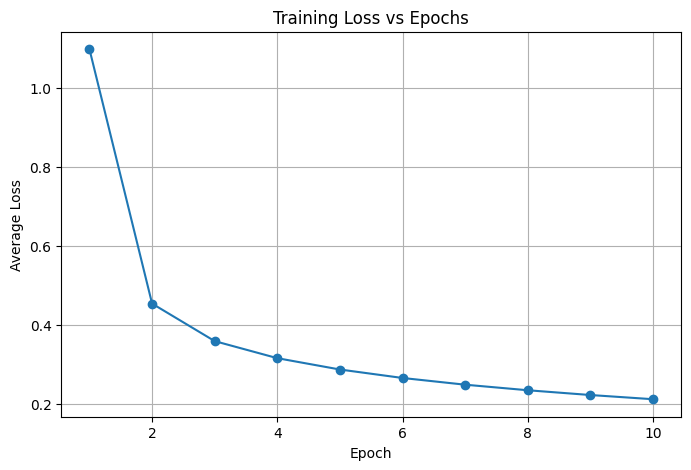

In [15]:
#epochs v/s loss

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), epoch_losses, marker='o')
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.show()


In [16]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# ---------- EVALUATION ----------
y_true = []
y_pred = []

for i in range(X_test_flat.shape[0]):
    X = X_test_flat[i].reshape(784,1)
    y = y_test[i].reshape(10,1)
    y_hat, _ = forward_prop(X, parameters)

    y_true.append(np.argmax(y))     # actual digit
    y_pred.append(np.argmax(y_hat)) # predicted digit

y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [17]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_true, y_pred))


Test Accuracy: 94.19%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.98      0.99      0.98      1135
           2       0.95      0.92      0.93      1032
           3       0.93      0.93      0.93      1010
           4       0.95      0.95      0.95       982
           5       0.93      0.91      0.92       892
           6       0.94      0.96      0.95       958
           7       0.95      0.93      0.94      1028
           8       0.92      0.92      0.92       974
           9       0.92      0.94      0.93      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



<Figure size 800x600 with 0 Axes>

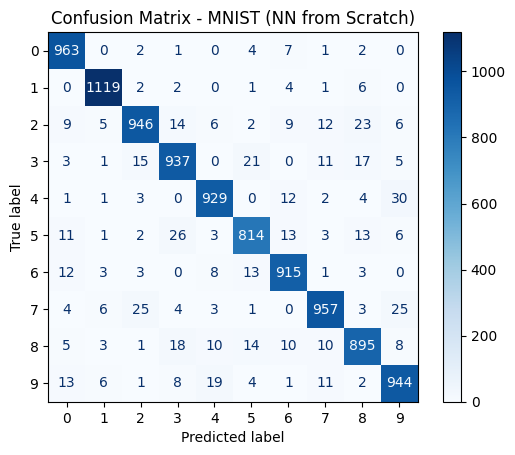

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - MNIST (NN from Scratch)")
plt.show()


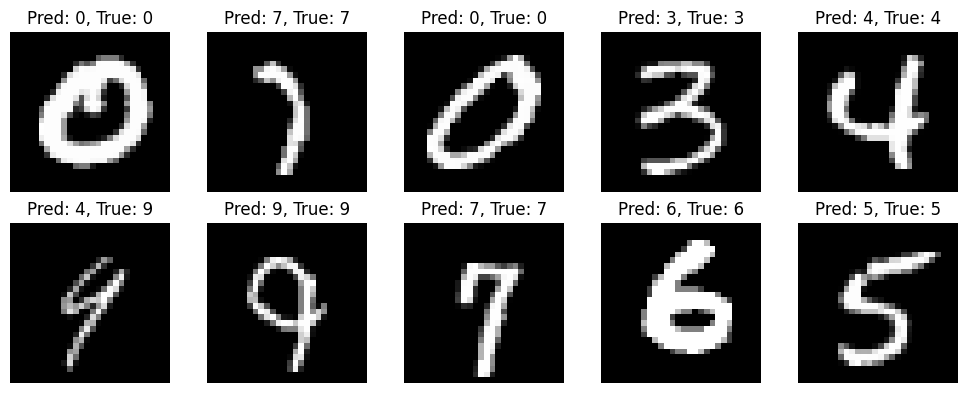

In [20]:
plt.figure(figsize=(10,4))
for i in range(10):
    idx = np.random.randint(0, len(X_test_flat))
    img = X_test_flat[idx].reshape(28,28)
    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {y_pred[idx]}, True: {y_true[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()